# Gaussian Process Regression (GPR)

In [ ]:

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

from pathlib import Path
PROJECT = Path('/content/drive/MyDrive/MSC THESIS')
DATA_DIR = PROJECT / 'ml_dataset' / 'data' / 'model_ready' / 'movie_success_v6'
RUN_DIR = DATA_DIR / 'colab_runs_v2'
RUN_DIR.mkdir(parents=True, exist_ok=True)

for f in ['movie_features_v6.csv', 'movie_features_v6_synthetic.csv',
          'scene_movie_metadata_v6.csv', 'scene_movie_metadata_v6_synthetic.csv']:
    assert (DATA_DIR / f).exists(), f'Missing: {f}'
print('Data dir:', DATA_DIR)

Mounted at /content/drive
Data dir: /content/drive/MyDrive/MSC THESIS/ml_dataset/data/model_ready/movie_success_v6


In [2]:
import warnings; warnings.filterwarnings('ignore')
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    LeaveOneOut, KFold, GridSearchCV, cross_val_predict,
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
)
from scipy.stats import spearmanr, pearsonr

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 180)
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)
print('Imports OK')

Imports OK


# Data loading

In [ ]:

real_mov  = pd.read_csv(DATA_DIR / 'movie_features_v6.csv')
syn_mov   = pd.read_csv(DATA_DIR / 'movie_features_v6_synthetic.csv')
real_meta = pd.read_csv(DATA_DIR / 'scene_movie_metadata_v6.csv')
syn_meta  = pd.read_csv(DATA_DIR / 'scene_movie_metadata_v6_synthetic.csv')

# Drop target / leakage columns from movie_features so we can re-merge cleanly
LEAKAGE_AND_OLD_TARGETS = [
    'budget_usd', 'revenue_usd', 'roi_percent', 'success_class',
    'imdb_rating', 'wom_multiplier', 'wom_multiplier_log',
]
real_mov = real_mov.drop(columns=LEAKAGE_AND_OLD_TARGETS, errors='ignore')
syn_mov  = syn_mov.drop(columns=LEAKAGE_AND_OLD_TARGETS, errors='ignore')

# Columns from metadata to use as features (excluding IDs, text, leakage)
META_KEEP = [
    'movie_id',
    # Scene properties (will be encoded below)
    'targeted_emotion', 'clip_duration_s',
    'cut_count', 'brightness', 'motion_intensity', 'audio_loudness',
    'silence_ratio', 'music_presence', 'dialogue_density',
    'face_screen_time_ratio', 'lead_screen_time_ratio',
    # Movie metadata
    'release_year', 'genre_primary', 'genre_secondary',
    'country_of_origin', 'budget_categorical',
    # Targets (kept to extract y; not used as features)
    'imdb_rating', 'wom_multiplier', 'wom_multiplier_log',
]
real_meta_sub = real_meta[[c for c in META_KEEP if c in real_meta.columns]]
syn_meta_sub  = syn_meta[[c for c in META_KEEP if c in syn_meta.columns]]

real_mov = real_mov.merge(real_meta_sub, on='movie_id', how='left')
real_mov['is_synthetic'] = 0
syn_mov = syn_mov.merge(syn_meta_sub, on='movie_id', how='left')
syn_mov['is_synthetic'] = 1

df_all = pd.concat([real_mov, syn_mov], ignore_index=True)
print(f'Real:      {len(real_mov)} movies')
print(f'Synthetic: {len(syn_mov)} movies')
print(f'Combined:  {len(df_all)} movies × {len(df_all.columns)} columns (pre-encoding)')
print()
print('Target distributions (pre-encoding):')
display(df_all[['is_synthetic', 'imdb_rating', 'wom_multiplier_log']]
        .groupby('is_synthetic').describe().round(2))

Real:      10 movies
Synthetic: 40 movies
Combined:  50 movies × 343 columns (pre-encoding)

Target distributions (pre-encoding):


imdb_rating                                        wom_multiplier_log                                          
                   count  mean   std  min  25%   50%   75%  max              count  mean   std   min   25%   50%   75%   max
is_synthetic                                                                                                                
0                   10.0  7.41  0.73  6.5  6.8  7.45  8.02  8.5               10.0  1.77  0.64  0.75  1.28  1.88  2.21  2.73
1                   40.0  7.48  0.55  6.5  7.0  7.50  7.82  8.4               40.0  1.70  0.54  0.34  1.28  1.86  2.04  2.91

# Feature preparation

In [ ]:


DROP = {
    'movie_id', 'condition', 'n_participants',
    # Targets (cannot be features)
    'imdb_rating', 'wom_multiplier', 'wom_multiplier_log',
    # Control flag (not a feature)
    'is_synthetic',
}

df_feat = df_all.copy()

# ── Ordinal encoding: low / moderate / high → 1 / 2 / 3 ──
ORD_MAP = {'low': 1, 'moderate': 2, 'high': 3}
ORD_COLS = ['cut_count', 'brightness', 'motion_intensity', 'audio_loudness',
            'silence_ratio', 'music_presence', 'dialogue_density',
            'face_screen_time_ratio', 'lead_screen_time_ratio',
            'budget_categorical']
for c in ORD_COLS:
    if c in df_feat.columns:
        df_feat[c] = df_feat[c].map(ORD_MAP)

# ── One-hot encode multi-category text columns ──
OH_COLS = ['targeted_emotion', 'genre_primary', 'genre_secondary', 'country_of_origin']
OH_COLS = [c for c in OH_COLS if c in df_feat.columns]
df_feat = pd.get_dummies(df_feat, columns=OH_COLS, prefix_sep='_',
                         dummy_na=False, dtype=int)

# ── Build feature matrix ──
feature_cols = [c for c in df_feat.columns if c not in DROP]
X_all = df_feat[feature_cols].apply(pd.to_numeric, errors='coerce')
y_imdb_all = df_feat['imdb_rating'].astype(float)
y_wom_all  = df_feat['wom_multiplier_log'].astype(float)
groups_all = df_feat['movie_id'].values if 'movie_id' in df_feat.columns else np.arange(len(df_feat))
synth_mask_all = df_feat['is_synthetic'].values.astype(bool)

# Drop all-NaN columns
all_nan_cols = X_all.columns[X_all.isna().all()].tolist()
if all_nan_cols:
    print(f'Dropping {len(all_nan_cols)} all-NaN columns')
    X_all = X_all.drop(columns=all_nan_cols)

# Drop zero-variance columns
zero_var_cols = X_all.columns[X_all.std() == 0].tolist()
if zero_var_cols:
    print(f'Dropping {len(zero_var_cols)} zero-variance columns')
    X_all = X_all.drop(columns=zero_var_cols)

feature_cols = list(X_all.columns)

#Categorise final features for transparency
phys_cols = [c for c in feature_cols if c.endswith('__mean') or c.endswith('__std')]
ord_in_X  = [c for c in feature_cols if c in ORD_COLS]
oh_in_X   = [c for c in feature_cols
             if any(c.startswith(p + '_') for p in
                    ['targeted_emotion', 'genre_primary', 'genre_secondary',
                     'country_of_origin'])]
other_cols = [c for c in feature_cols
              if c not in phys_cols + ord_in_X + oh_in_X]

print(f'\nFinal feature matrix: {X_all.shape}')
print(f'  Physiological (mean/std):  {len(phys_cols):>4d}')
print(f'  Scene/movie ordinal:       {len(ord_in_X):>4d}  ({ord_in_X})')
print(f'  Scene/movie one-hot:       {len(oh_in_X):>4d}')
print(f'  Other numeric (year, dur): {len(other_cols):>4d}  ({other_cols})')
print(f'  TOTAL features:            {len(feature_cols):>4d}')


Final feature matrix: (50, 360)
  Physiological (mean/std):   320
  Scene/movie ordinal:         10  (['cut_count', 'brightness', 'motion_intensity', 'audio_loudness', 'silence_ratio', 'music_presence', 'dialogue_density', 'face_screen_time_ratio', 'lead_screen_time_ratio', 'budget_categorical'])
  Scene/movie one-hot:         28
  Other numeric (year, dur):    2  (['clip_duration_s', 'release_year'])
  TOTAL features:             360


# Evaluation helpers

In [5]:
def regression_metrics(y_true, y_pred):
    mask = ~(np.isnan(y_pred) | np.isnan(y_true))
    yt, yp = np.asarray(y_true)[mask], np.asarray(y_pred)[mask]
    if len(yt) < 3:
        return {'n': len(yt), 'r2': np.nan, 'mae': np.nan, 'rmse': np.nan,
                'spearman': np.nan, 'pearson': np.nan}
    return {
        'n': len(yt),
        'r2': r2_score(yt, yp),
        'mae': mean_absolute_error(yt, yp),
        'rmse': np.sqrt(mean_squared_error(yt, yp)),
        'spearman': spearmanr(yt, yp).correlation,
        'pearson': pearsonr(yt, yp)[0],
    }

def loo_predict(estimator, X, y):
    return cross_val_predict(estimator, X, y, cv=LeaveOneOut(), n_jobs=-1)

def kfold_predict(estimator, X, y, n_splits=5, random_state=42):
    return cross_val_predict(estimator, X, y,
                            cv=KFold(n_splits=n_splits, shuffle=True,
                                    random_state=random_state),
                            n_jobs=-1)

def report(metrics, title=''):
    print(f'\n──── {title} ────')
    for k, v in metrics.items():
        if k == 'n': print(f'  {k:>10s}: {v}')
        else: print(f'  {k:>10s}: {v:.3f}' if not np.isnan(v) else f'  {k:>10s}: NaN')

def plot_pred_vs_actual(y_true, y_pred, title, ax=None, y_std=None):
    if ax is None: fig, ax = plt.subplots(figsize=(5, 5))
    mask = ~(np.isnan(y_pred) | np.isnan(y_true))
    yt, yp = np.asarray(y_true)[mask], np.asarray(y_pred)[mask]
    if y_std is not None:
        ys = np.asarray(y_std)[mask]
        ax.errorbar(yt, yp, yerr=ys, fmt='o', alpha=0.6,
                    capsize=2, ecolor='gray', markersize=6)
    else:
        ax.scatter(yt, yp, alpha=0.6, s=40, edgecolor='k', linewidth=0.5)
    lo, hi = min(yt.min(), yp.min()), max(yt.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], 'r--', alpha=0.5, label='y = x')
    r2 = r2_score(yt, yp)
    rho = spearmanr(yt, yp).correlation
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(f'{title}\nR²={r2:.2f}, Spearman ρ={rho:.2f}')
    ax.legend(); ax.grid(alpha=0.3)
    return ax

# Real-only (LOO CV, n = 10)

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel, RBF, Matern, WhiteKernel
)

mask_real = ~synth_mask_all
X_real = X_all[mask_real].reset_index(drop=True)
y_imdb_real = y_imdb_all[mask_real].reset_index(drop=True)
y_wom_real = y_wom_all[mask_real].reset_index(drop=True)

def make_gpr_pipeline(kernel_type='ard_rbf'):
    n_features_inferred = X_all.shape[1]   # uses available feature count
    if kernel_type == 'ard_rbf':
        kernel = (ConstantKernel(1.0, (1e-3, 1e3))
                  * RBF(length_scale=np.ones(n_features_inferred),
                        length_scale_bounds=(1e-2, 1e3))
                  + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)))
    elif kernel_type == 'ard_matern25':
        kernel = (ConstantKernel(1.0, (1e-3, 1e3))
                  * Matern(length_scale=np.ones(n_features_inferred), nu=2.5,
                           length_scale_bounds=(1e-2, 1e3))
                  + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)))
    elif kernel_type == 'ard_matern15':
        kernel = (ConstantKernel(1.0, (1e-3, 1e3))
                  * Matern(length_scale=np.ones(n_features_inferred), nu=1.5,
                           length_scale_bounds=(1e-2, 1e3))
                  + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)))
    elif kernel_type == 'iso_rbf':           # isotropic RBF (single length-scale)
        kernel = (ConstantKernel(1.0, (1e-3, 1e3))
                  * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e3))
                  + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)))
    else:
        raise ValueError(kernel_type)
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', GaussianProcessRegressor(
            kernel=kernel,
            n_restarts_optimizer=20,         
            normalize_y=True,
            alpha=1e-8,                       
            random_state=42)),
    ])

# Baseline: ARD-RBF
pipe = make_gpr_pipeline('ard_rbf')
y_pred = loo_predict(pipe, X_real, y_imdb_real)
metrics_real_imdb_baseline = regression_metrics(y_imdb_real, y_pred)
report(metrics_real_imdb_baseline, 'Real / IMDb / baseline (ARD-RBF)')

pipe = make_gpr_pipeline('ard_rbf')
y_pred = loo_predict(pipe, X_real, y_wom_real)
metrics_real_wom_baseline = regression_metrics(y_wom_real, y_pred)
report(metrics_real_wom_baseline, 'Real / WOM / baseline (ARD-RBF)')


──── Real / IMDb / baseline (ARD-RBF) ────
           n: 10
          r2: -0.235
         mae: 0.678
        rmse: 0.774
    spearman: -1.000
     pearson: -1.000

──── Real / WOM / baseline (ARD-RBF) ────
           n: 10
          r2: -0.235
         mae: 0.573
        rmse: 0.671
    spearman: -1.000
     pearson: -1.000


# Kernel selection (LOO grid)

In [ ]:
# Tune over kernel TYPE (ARD-RBF, ARD-Matern-1.5, ARD-Matern-2.5, isotropic-RBF).
# Kernel hyperparameters within each are auto-optimised
def cv_score_kernel(kernel_type, X, y, cv):
    pipe = make_gpr_pipeline(kernel_type)
    y_pred = cross_val_predict(pipe, X, y, cv=cv, n_jobs=-1)
    return regression_metrics(y, y_pred), y_pred

KERNEL_TYPES = ['ard_rbf', 'ard_matern25', 'ard_matern15', 'iso_rbf']

results_imdb = {}
for kt in KERNEL_TYPES:
    m, _ = cv_score_kernel(kt, X_real, y_imdb_real, LeaveOneOut())
    results_imdb[kt] = m
    print(f'  Real / IMDb / {kt:14s}: MAE={m["mae"]:.3f}, '
          f'R²={m["r2"]:.3f}, Spearman={m["spearman"]:.2f}')

best_kernel_imdb = min(results_imdb, key=lambda k: results_imdb[k]['mae'])
best_params_imdb_real = {'model__kernel': best_kernel_imdb}
metrics_real_imdb_tuned, y_pred_real_imdb_tuned = cv_score_kernel(
    best_kernel_imdb, X_real, y_imdb_real, LeaveOneOut())
print(f'\nBest IMDb kernel: {best_kernel_imdb}')
report(metrics_real_imdb_tuned, 'Real / IMDb / tuned')

results_wom = {}
for kt in KERNEL_TYPES:
    m, _ = cv_score_kernel(kt, X_real, y_wom_real, LeaveOneOut())
    results_wom[kt] = m
    print(f'  Real / WOM  / {kt:14s}: MAE={m["mae"]:.3f}, '
          f'R²={m["r2"]:.3f}, Spearman={m["spearman"]:.2f}')

best_kernel_wom = min(results_wom, key=lambda k: results_wom[k]['mae'])
best_params_wom_real = {'model__kernel': best_kernel_wom}
metrics_real_wom_tuned, y_pred_real_wom_tuned = cv_score_kernel(
    best_kernel_wom, X_real, y_wom_real, LeaveOneOut())
print(f'\nBest WOM kernel: {best_kernel_wom}')
report(metrics_real_wom_tuned, 'Real / WOM / tuned')

  Real / IMDb / ard_rbf       : MAE=0.678, R²=-0.235, Spearman=-1.00
  Real / IMDb / ard_matern25  : MAE=0.678, R²=-0.235, Spearman=-1.00
  Real / IMDb / ard_matern15  : MAE=0.678, R²=-0.235, Spearman=-1.00
  Real / IMDb / iso_rbf       : MAE=0.678, R²=-0.235, Spearman=-1.00

Best IMDb kernel: ard_rbf

──── Real / IMDb / tuned ────
           n: 10
          r2: -0.235
         mae: 0.678
        rmse: 0.774
    spearman: -1.000
     pearson: -1.000
  Real / WOM  / ard_rbf       : MAE=0.573, R²=-0.235, Spearman=-1.00
  Real / WOM  / ard_matern25  : MAE=0.573, R²=-0.235, Spearman=-1.00
  Real / WOM  / ard_matern15  : MAE=0.573, R²=-0.235, Spearman=-1.00
  Real / WOM  / iso_rbf       : MAE=0.573, R²=-0.235, Spearman=-1.00

Best WOM kernel: ard_rbf

──── Real / WOM / tuned ────
           n: 10
          r2: -0.235
         mae: 0.573
        rmse: 0.671
    spearman: -1.000
     pearson: -1.000


# Posterior uncertainty (the key advantage of this model)

In [8]:
# For each held-out movie, get the prediction's posterior std.
# This is the unique selling point of GPR: principled CIs at small n.

def loo_predict_with_std(pipe_factory, kernel_type, X, y):
    """Returns (y_pred, y_std) using LOO; refits per fold."""
    n = len(y)
    y_pred = np.empty(n)
    y_std  = np.empty(n)
    for i in range(n):
        idx = np.arange(n) != i
        pipe = pipe_factory(kernel_type)
        pipe.fit(X.iloc[idx], y.iloc[idx])
        # Need to access the GPR step to get std
        X_test_imp = pipe.named_steps['imputer'].transform(X.iloc[[i]])
        X_test_sc  = pipe.named_steps['scaler'].transform(X_test_imp)
        mu, sigma = pipe.named_steps['model'].predict(X_test_sc, return_std=True)
        y_pred[i] = mu[0]; y_std[i] = sigma[0]
    return y_pred, y_std

print('Computing LOO predictions with posterior std (IMDb, real-only)...')
y_pred_real_imdb_with_std, y_std_real_imdb = loo_predict_with_std(
    make_gpr_pipeline, best_kernel_imdb, X_real, y_imdb_real)

print(f'\nMovie-by-movie predictions (real, IMDb):')
print(f'  {"movie_idx":>10s}  {"actual":>8s}  {"predicted":>10s}  {"±std":>8s}')
for i in range(len(y_imdb_real)):
    print(f'  {i:>10d}  {y_imdb_real.iloc[i]:>8.2f}  '
          f'{y_pred_real_imdb_with_std[i]:>10.2f}  ±{y_std_real_imdb[i]:.2f}')

# Recompute metrics from these predictions
metrics_real_imdb_tuned = regression_metrics(y_imdb_real, y_pred_real_imdb_with_std)
print(f'\nFinal real / IMDb / tuned metrics with posterior:')
report(metrics_real_imdb_tuned, '')

Computing LOO predictions with posterior std (IMDb, real-only)...

Movie-by-movie predictions (real, IMDb):
   movie_idx    actual   predicted      ±std
           0      7.80        7.37  ±0.72
           1      8.20        7.32  ±0.68
           2      8.10        7.33  ±0.69
           3      6.80        7.48  ±0.70
           4      8.50        7.29  ±0.63
           5      7.40        7.41  ±0.73
           6      6.50        7.51  ±0.66
           7      6.50        7.51  ±0.66
           8      7.50        7.40  ±0.73
           9      6.80        7.48  ±0.70

Final real / IMDb / tuned metrics with posterior:

────  ────
           n: 10
          r2: -0.235
         mae: 0.678
        rmse: 0.774
    spearman: -1.000
     pearson: -1.000


In [9]:
# Same for WOM
print('Computing LOO predictions with posterior std (WOM, real-only)...')
y_pred_real_wom_with_std, y_std_real_wom = loo_predict_with_std(
    make_gpr_pipeline, best_kernel_wom, X_real, y_wom_real)
metrics_real_wom_tuned = regression_metrics(y_wom_real, y_pred_real_wom_with_std)
report(metrics_real_wom_tuned, 'Real / WOM / tuned (with posterior std)')

Computing LOO predictions with posterior std (WOM, real-only)...

──── Real / WOM / tuned (with posterior std) ────
           n: 10
          r2: -0.235
         mae: 0.573
        rmse: 0.671
    spearman: -1.000
     pearson: -1.000


# Augmented (5-fold CV, n = 50)

In [10]:
# Baseline ARD-RBF
pipe = make_gpr_pipeline('ard_rbf')
y_pred_aug_imdb = kfold_predict(pipe, X_all, y_imdb_all, n_splits=5)
metrics_aug_imdb_baseline = regression_metrics(y_imdb_all, y_pred_aug_imdb)
report(metrics_aug_imdb_baseline, 'Augmented / IMDb / baseline (ARD-RBF)')

pipe = make_gpr_pipeline('ard_rbf')
y_pred_aug_wom = kfold_predict(pipe, X_all, y_wom_all, n_splits=5)
metrics_aug_wom_baseline = regression_metrics(y_wom_all, y_pred_aug_wom)
report(metrics_aug_wom_baseline, 'Augmented / WOM / baseline (ARD-RBF)')


──── Augmented / IMDb / baseline (ARD-RBF) ────
           n: 50
          r2: -0.013
         mae: 0.500
        rmse: 0.579
    spearman: -0.171
     pearson: -0.155

──── Augmented / WOM / baseline (ARD-RBF) ────
           n: 50
          r2: -0.028
         mae: 0.460
        rmse: 0.556
    spearman: -0.219
     pearson: -0.224


In [11]:
# Tuned: select best kernel via 5-fold CV
results_aug_imdb = {}
for kt in KERNEL_TYPES:
    m, _ = cv_score_kernel(kt, X_all, y_imdb_all,
                           KFold(5, shuffle=True, random_state=42))
    results_aug_imdb[kt] = m
    print(f'  Aug / IMDb / {kt:14s}: MAE={m["mae"]:.3f}, '
          f'R²={m["r2"]:.3f}, Spearman={m["spearman"]:.2f}')

best_kernel_imdb_aug = min(results_aug_imdb, key=lambda k: results_aug_imdb[k]['mae'])
best_params_imdb = {'model__kernel': best_kernel_imdb_aug}
metrics_aug_imdb_tuned, y_pred_aug_imdb_tuned = cv_score_kernel(
    best_kernel_imdb_aug, X_all, y_imdb_all,
    KFold(5, shuffle=True, random_state=42))
print(f'\nBest IMDb kernel: {best_kernel_imdb_aug}')
report(metrics_aug_imdb_tuned, 'Augmented / IMDb / tuned')

results_aug_wom = {}
for kt in KERNEL_TYPES:
    m, _ = cv_score_kernel(kt, X_all, y_wom_all,
                           KFold(5, shuffle=True, random_state=42))
    results_aug_wom[kt] = m
    print(f'  Aug / WOM  / {kt:14s}: MAE={m["mae"]:.3f}, '
          f'R²={m["r2"]:.3f}, Spearman={m["spearman"]:.2f}')

best_kernel_wom_aug = min(results_aug_wom, key=lambda k: results_aug_wom[k]['mae'])
best_params_wom = {'model__kernel': best_kernel_wom_aug}
metrics_aug_wom_tuned, y_pred_aug_wom_tuned = cv_score_kernel(
    best_kernel_wom_aug, X_all, y_wom_all,
    KFold(5, shuffle=True, random_state=42))
print(f'\nBest WOM kernel: {best_kernel_wom_aug}')
report(metrics_aug_wom_tuned, 'Augmented / WOM / tuned')

  Aug / IMDb / ard_rbf       : MAE=0.500, R²=-0.013, Spearman=-0.17
  Aug / IMDb / ard_matern25  : MAE=0.500, R²=-0.013, Spearman=-0.17
  Aug / IMDb / ard_matern15  : MAE=0.500, R²=-0.013, Spearman=-0.09
  Aug / IMDb / iso_rbf       : MAE=0.319, R²=0.454, Spearman=0.66

Best IMDb kernel: iso_rbf

──── Augmented / IMDb / tuned ────
           n: 50
          r2: 0.454
         mae: 0.319
        rmse: 0.425
    spearman: 0.661
     pearson: 0.674
  Aug / WOM  / ard_rbf       : MAE=0.460, R²=-0.028, Spearman=-0.22
  Aug / WOM  / ard_matern25  : MAE=0.460, R²=-0.028, Spearman=-0.22
  Aug / WOM  / ard_matern15  : MAE=0.460, R²=-0.028, Spearman=-0.15
  Aug / WOM  / iso_rbf       : MAE=0.431, R²=0.063, Spearman=0.30

Best WOM kernel: iso_rbf

──── Augmented / WOM / tuned ────
           n: 50
          r2: 0.063
         mae: 0.431
        rmse: 0.531
    spearman: 0.300
     pearson: 0.254


# Visuals(with posterior uncertainty for real-only)

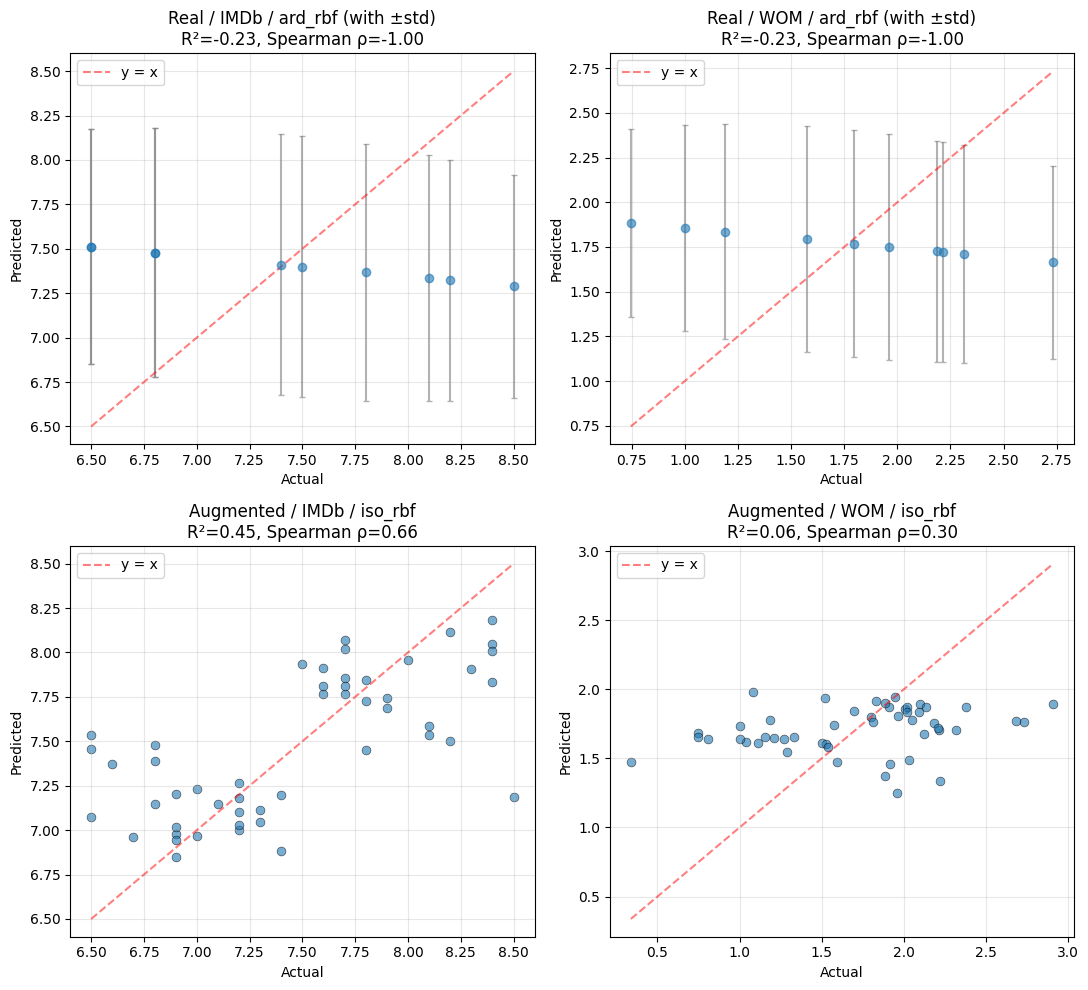

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
# Real-only: show error bars from posterior std
plot_pred_vs_actual(y_imdb_real, y_pred_real_imdb_with_std,
                    f'Real / IMDb / {best_kernel_imdb} (with ±std)',
                    axes[0, 0], y_std=y_std_real_imdb)
plot_pred_vs_actual(y_wom_real, y_pred_real_wom_with_std,
                    f'Real / WOM / {best_kernel_wom} (with ±std)',
                    axes[0, 1], y_std=y_std_real_wom)
plot_pred_vs_actual(y_imdb_all, y_pred_aug_imdb_tuned,
                    f'Augmented / IMDb / {best_kernel_imdb_aug}', axes[1, 0])
plot_pred_vs_actual(y_wom_all, y_pred_aug_wom_tuned,
                    f'Augmented / WOM / {best_kernel_wom_aug}', axes[1, 1])
plt.tight_layout(); plt.show()

## 8 · Posterior calibration check

In [ ]:

true_y = np.asarray(y_imdb_real)
pred_y = y_pred_real_imdb_with_std
std_y  = y_std_real_imdb
within_1 = np.abs(true_y - pred_y) < std_y
within_2 = np.abs(true_y - pred_y) < 2 * std_y
print(f'IMDb posterior calibration (real-only, n={len(true_y)}):')
print(f'  {within_1.sum()}/{len(true_y)} ({within_1.mean()*100:.0f}%) within ±1 std  '
      f'(ideal: 68%)')
print(f'  {within_2.sum()}/{len(true_y)} ({within_2.mean()*100:.0f}%) within ±2 std  '
      f'(ideal: 95%)')

true_y = np.asarray(y_wom_real)
pred_y = y_pred_real_wom_with_std
std_y  = y_std_real_wom
within_1 = np.abs(true_y - pred_y) < std_y
within_2 = np.abs(true_y - pred_y) < 2 * std_y
print(f'\nWOM posterior calibration (real-only, n={len(true_y)}):')
print(f'  {within_1.sum()}/{len(true_y)} ({within_1.mean()*100:.0f}%) within ±1 std')
print(f'  {within_2.sum()}/{len(true_y)} ({within_2.mean()*100:.0f}%) within ±2 std')

IMDb posterior calibration (real-only, n=10):
  5/10 (50%) within ±1 std  (ideal: 68%)
  10/10 (100%) within ±2 std  (ideal: 95%)

WOM posterior calibration (real-only, n=10):
  6/10 (60%) within ±1 std
  9/10 (90%) within ±2 std


In [14]:
out_path = RUN_DIR / 'results_gaussian_process.json'
results_to_save = {
    'model': 'gaussian_process',
    'feature_count': len(feature_cols),
    'best_params_imdb': best_params_imdb,
    'best_params_wom':  best_params_wom,
    'metrics_real_imdb_baseline': metrics_real_imdb_baseline,
    'metrics_real_wom_baseline':  metrics_real_wom_baseline,
    'metrics_real_imdb_tuned':    metrics_real_imdb_tuned,
    'metrics_real_wom_tuned':     metrics_real_wom_tuned,
    'metrics_aug_imdb_baseline':  metrics_aug_imdb_baseline,
    'metrics_aug_wom_baseline':   metrics_aug_wom_baseline,
    'metrics_aug_imdb_tuned':     metrics_aug_imdb_tuned,
    'metrics_aug_wom_tuned':      metrics_aug_wom_tuned,
}
with open(out_path, 'w') as f:
    json.dump(results_to_save, f, indent=2, default=str)
print(f'Saved → {out_path}')

Saved → /content/drive/MyDrive/MSC THESIS/ml_dataset/data/model_ready/movie_success_v6/colab_runs_v2/results_gaussian_process.json
